# 拉普拉斯变换与拉普拉斯逆变换：SymPy 和 Matplotlib 演示

**目标。** 本 Notebook 介绍单边拉普拉斯变换及其逆变换的定义、应用场景和工程意义；随后选取一个阻尼正弦信号，使用 `sympy` 完成符号推导，并使用 `matplotlib` 绘制支持中文标注的时域、频率响应和重构图。

> 建议运行环境：Python 3.10+，SymPy，NumPy，Matplotlib。若本机没有中文字体，图表中的中文可能无法正常显示；本 Notebook 已按优先级自动选择可用的中文字体。

## 1. 定义与符号约定

对因果信号 $x(t)$，其**单边拉普拉斯变换**定义为：

$$
X(s)=\mathcal{L}\{x(t)\}=\int_{0^-}^{\infty}x(t)e^{-st}\,\mathrm{d}t,
$$

其中复变量 $s=\sigma+j\omega$。这里，$\sigma$ 是实部，$\omega$ 是角频率，$j^2=-1$。当积分收敛时，$X(s)$ 定义在 $s$ 平面的一块区域中，称为**收敛域**（Region of Convergence, ROC）。

拉普拉斯逆变换可用复积分表示：

$$
x(t)=\mathcal{L}^{-1}\{X(s)\}=\frac{1}{2\pi j}\int_{\gamma-j\infty}^{\gamma+j\infty}X(s)e^{st}\,\mathrm{d}s,
$$

其中积分路径位于收敛域内。实际计算中，通常依据变换表、部分分式分解，或调用符号计算工具完成。

本 Notebook 使用 SymPy 的 `laplace_transform` 与 `inverse_laplace_transform`。前者返回变换表达式、收敛半平面边界和附加收敛条件；官方文档给出了同一变换定义及接口说明。[1]

## 2. 应用场景与意义

拉普拉斯变换把时域中的微分方程转化为 $s$ 域中的代数方程，并可在一个统一框架内处理零初始条件、指数衰减、阶跃输入以及系统稳定性问题。因此，它是连续时间系统分析与控制工程中的核心工具。

| 场景 | 拉普拉斯变换的作用 | 工程意义 |
|---|---|---|
| 电路暂态分析 | 将电阻、电容、电感构成的微分关系转化为阻抗形式 | 便于求解开关瞬态和响应过程 |
| 控制系统 | 得到传递函数 $G(s)$，分析极点、零点与稳定性 | 支撑闭环设计、动态性能评估与补偿 |
| 常微分方程 | 将微分运算转化为关于 $s$ 的乘法关系 | 可系统处理初值问题 |
| 信号与系统 | 同时描述增长/衰减行为和频率成分 | 比仅使用傅里叶变换更适于暂态与非稳定信号 |
| 机械振动 | 表示质量—弹簧—阻尼系统的动态模型 | 用于共振、阻尼和响应预测 |

> **重要理解：** 当收敛域包含虚轴 $s=j\omega$ 时，在虚轴上取值 $X(j\omega)$ 便与傅里叶变换的频率响应相联系。

## 3. 导入库并设置中文绘图字体

以下代码会检测可用字体并优先选择常见的中文字体。设置 `axes.unicode_minus=False` 可避免坐标轴负号显示异常。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sympy as sp
from sympy import (
    I, exp, sin, laplace_transform, inverse_laplace_transform,
    symbols, simplify
)

# 按优先级寻找中文字体；不同操作系统的字体名称可能不同。
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = [
    'Noto Sans CJK SC', 'Noto Sans CJK', 'WenQuanYi Zen Hei',
    'SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS'
]
selected_font = next((name for name in font_candidates if name in available_fonts), 'DejaVu Sans')

plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print(f'当前绘图字体：{selected_font}')
print(f'SymPy 版本：{sp.__version__}')

当前绘图字体：SimHei
SymPy 版本：1.14.0


## 4. 使用 SymPy 计算拉普拉斯变换和逆变换

选取因果阻尼正弦信号：

$$
x(t)=e^{-at}\sin(\omega_0 t), \qquad a>0, \ \omega_0>0.
$$

其中，$a$ 决定指数衰减速度，$\omega_0$ 决定振荡频率。该信号的拉普拉斯变换为有理函数，适合观察 $s$ 域中的极点及逆变换的重构结果。

In [2]:
# 建立符号变量。a 与 w0 为正数，符合阻尼率和角频率的物理含义。
t, s, a, w0 = symbols('t s a w0', real=True, positive=True)

# 时域阻尼正弦信号
x_t = exp(-a * t) * sin(w0 * t)

# SymPy 返回：(变换结果，收敛半平面边界，附加收敛条件)。
X_s, convergence_plane, convergence_condition = laplace_transform(x_t, t, s)

# 对 X(s) 执行拉普拉斯逆变换。
x_reconstructed = inverse_laplace_transform(X_s, s, t)

print('时域信号 x(t) =')
sp.pprint(x_t)
print('\n拉普拉斯变换 X(s) =')
sp.pprint(X_s)
print(f'\n收敛域：Re(s) > {convergence_plane}')
print(f'附加条件：{convergence_condition}')
print('\n逆变换得到的信号 x̂(t) =')
sp.pprint(x_reconstructed)
print('\n在 t > 0 上的符号验证 x̂(t) - x(t) =')
sp.pprint(simplify(x_reconstructed.subs(sp.Heaviside(t), 1) - x_t))

时域信号 x(t) =
 -a⋅t          
ℯ    ⋅sin(t⋅w₀)

拉普拉斯变换 X(s) =
      w₀      
──────────────
  2          2
w₀  + (a + s) 

收敛域：Re(s) > -a
附加条件：True

逆变换得到的信号 x̂(t) =
 -a⋅t          
ℯ    ⋅sin(t⋅w₀)

在 t > 0 上的符号验证 x̂(t) - x(t) =
0


## 5. 绘制时域波形与虚轴频率响应

取阻尼率 $a=0.7\,\mathrm{s}^{-1}$、固有角频率 $\omega_0=6\,\mathrm{rad/s}$。左图显示阻尼正弦信号随时间衰减；右图绘制 $s=j\omega$ 上的幅度 $|X(j\omega)|$。

由 $X(s)=\omega_0/[(s+a)^2+\omega_0^2]$ 可以看到极点位于 $s=-a\pm j\omega_0$。由于它们位于左半平面，信号随时间衰减，且收敛域包含虚轴。

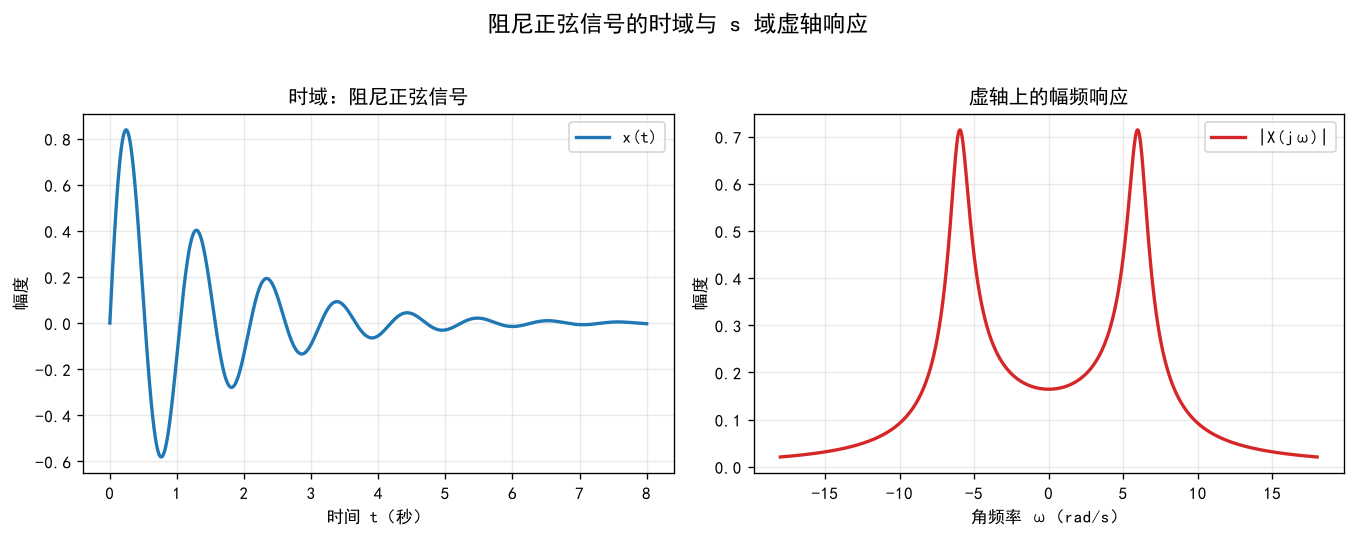

In [3]:
# 用具体参数生成数值曲线。
a_value = 0.7
w0_value = 6.0

x_t_numeric = x_t.subs({a: a_value, w0: w0_value})
X_s_numeric = X_s.subs({a: a_value, w0: w0_value})
X_jw = X_s_numeric.subs(s, I * sp.Symbol('omega', real=True))

x_fun = sp.lambdify(t, x_t_numeric, modules='numpy')
omega = sp.Symbol('omega', real=True)
X_jw_for_plot = X_s_numeric.subs(s, I * omega)
X_jw_fun = sp.lambdify(omega, X_jw_for_plot, modules='numpy')

time_values = np.linspace(0, 8, 1800)
omega_values = np.linspace(-18, 18, 1800)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))

axes[0].plot(time_values, x_fun(time_values), color='#1f77b4', linewidth=2.0, label='x(t)')
axes[0].set_title('时域：阻尼正弦信号')
axes[0].set_xlabel('时间 t（秒）')
axes[0].set_ylabel('幅度')
axes[0].grid(True, alpha=0.28)
axes[0].legend()

axes[1].plot(
    omega_values, np.abs(X_jw_fun(omega_values)),
    color='#d62728', linewidth=2.0, label='|X(jω)|'
)
axes[1].set_title('虚轴上的幅频响应')
axes[1].set_xlabel('角频率 ω（rad/s）')
axes[1].set_ylabel('幅度')
axes[1].grid(True, alpha=0.28)
axes[1].legend()

fig.suptitle('阻尼正弦信号的时域与 s 域虚轴响应', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

## 6. 使用拉普拉斯逆变换重构信号

下面把 SymPy 得到的逆变换结果与原始信号叠加显示，并计算逐点绝对误差。对于 $t\ge 0$，$\operatorname{Heaviside}(t)$ 为 1，因此逆变换结果应与原始因果信号重合。

C:\Users\yeshe\AppData\Local\Temp\ipykernel_40188\3203435008.py:29: UserWarning: Glyph 120 (x) missing from font(s) SimHei.
  fig.tight_layout()
d:\Source\Repos\Visual Studio Code\sensors_and_intelligent_detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 120 (x) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


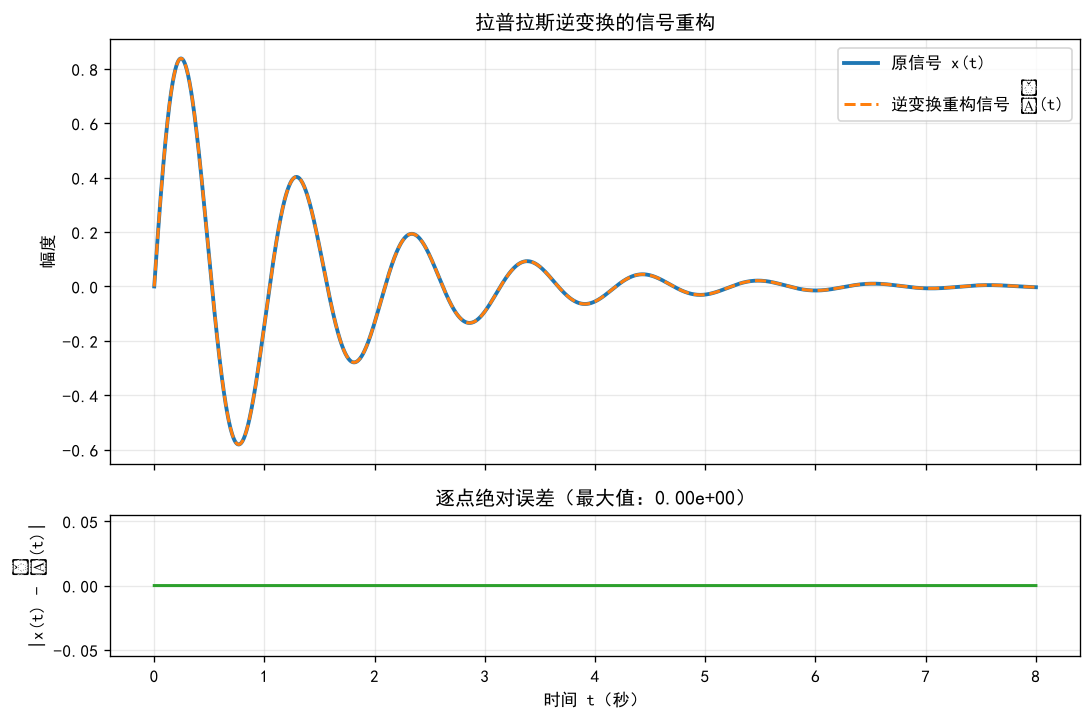

In [4]:
# 在 t > 0 的作图范围内，Heaviside(t)=1；可直接对逆变换表达式数值化。
x_reconstructed_numeric = simplify(
    x_reconstructed.subs({a: a_value, w0: w0_value, sp.Heaviside(t): 1})
)
x_reconstructed_fun = sp.lambdify(t, x_reconstructed_numeric, modules='numpy')

original_values = np.real_if_close(x_fun(time_values))
reconstructed_values = np.real_if_close(x_reconstructed_fun(time_values))
error_values = np.abs(original_values - reconstructed_values)

fig, axes = plt.subplots(2, 1, figsize=(9.2, 6.1), sharex=True, height_ratios=[3, 1])

axes[0].plot(time_values, original_values, color='#1f77b4', linewidth=2.3, label='原信号 x(t)')
axes[0].plot(
    time_values, reconstructed_values, color='#ff7f0e', linestyle='--',
    linewidth=1.8, label='逆变换重构信号 x̂(t)'
)
axes[0].set_title('拉普拉斯逆变换的信号重构')
axes[0].set_ylabel('幅度')
axes[0].grid(True, alpha=0.28)
axes[0].legend()

axes[1].plot(time_values, error_values, color='#2ca02c', linewidth=1.8)
axes[1].set_title(f'逐点绝对误差（最大值：{np.max(error_values):.2e}）')
axes[1].set_xlabel('时间 t（秒）')
axes[1].set_ylabel('|x(t) - x̂(t)|')
axes[1].grid(True, alpha=0.28)

fig.tight_layout()
plt.show()

## 7. 结论

本 Notebook 展示了以下要点：

1. **拉普拉斯变换**将连续时间信号映射到复变量 $s$ 的函数，能够同时表达指数增长/衰减与振荡特性。
2. **拉普拉斯逆变换**可以从 $s$ 域表达式恢复时域信号，是求解微分方程和系统响应的重要步骤。
3. 对阻尼正弦信号，SymPy 得到了闭式变换与逆变换；在 $t>0$ 范围内，重构结果与原信号一致。
4. 通过中文字体配置，Matplotlib 的标题、坐标轴、图例和误差说明均可正常显示中文。

### 参考资料

[1] SymPy Development Team. *Integral Transforms — SymPy Documentation*：https://docs.sympy.org/latest/modules/integrals/integrals.html

[2] A. V. Oppenheim, A. S. Willsky, with S. H. Nawab. *Signals and Systems*, 2nd ed., Prentice Hall, 1997.